# Player profile — Michael Olise

**Player-centric** BSQ view with **Finishing execution index** (post-strike execution percentiles).

In [1]:
# Run stamp — you should see this text below after selecting kernel BSQ Hackathon (.venv)
from datetime import datetime, timezone
import plotly.io as pio
from aws_football.bsq_reports import use_bsq_notebook_plotly

renderer = use_bsq_notebook_plotly()
print("=" * 60)
print("PLAYER PROFILE NOTEBOOK")
print("Executed:", datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"))
print("Plotly renderer:", renderer)
print("If charts below are empty: Kernel -> BSQ Hackathon (.venv), then Reload from Disk")
print("=" * 60)


PLAYER PROFILE NOTEBOOK
Executed: 2026-05-27 15:20 UTC
Plotly renderer: vscode
If charts below are empty: Kernel -> BSQ Hackathon (.venv), then Reload from Disk


### Highest mean scores (≥ 60)

Every BSQ metric with a shot-average **≥ 60** gets a speedometer (no top-N cap).


In [2]:
from pathlib import Path
from IPython.display import HTML, display
import pandas as pd
from aws_football.bsq_reports import (
    merge_shot_tables,
    player_summary,
    display_plotly_player_dashboard,
    display_plotly_speedometer,
    display_plotly_phase_speedometer,
    display_player_speedometers,
    notebook_plot_style_html,
    BACKSWING_PHASE_LABEL,
    FOLLOW_THROUGH_PHASE_LABEL,
    FINISHING_EXECUTION_INDEX_COL,
)

display(HTML(notebook_plot_style_html()))
PLAYER = 'Michael Olise'
df = merge_shot_tables()
olise = df[df.player_name == PLAYER].copy()
olise[['match_folder','family','shot_result', FINISHING_EXECUTION_INDEX_COL,'technique_mechanics_score','placement_score','strike_quality_score','P3_score','P4_score','P5_score']]


,match_folder,family,shot_result,finishing_execution_index,technique_mechanics_score,placement_score,strike_quality_score,P3_score,P4_score,P5_score
0,Bayern_Hamburg,dead_ball,blockedShot,66.798618,81.379179,79.180644,82.256349,85.013498,80.860774,81.385589
3,Bayern_Hamburg,carry_self_created,savedShot,53.853715,67.894631,63.079728,73.539406,78.096028,83.261458,35.252925
15,Bayern_Hamburg,open_play,savedShot,65.235503,68.897980,62.394464,76.284124,74.357554,79.893814,68.816800
19,Bayern_Hamburg,long_range,savedShot,45.604214,68.514737,53.973345,66.542252,80.137768,67.040835,51.199261
28,Bayern_Hamburg,open_play,blockedShot,57.612665,83.061062,61.205346,74.225499,78.805894,79.940481,95.340314
113,Union_Bayern,open_play,savedShot,49.927046,73.169967,83.513189,68.791835,73.717617,65.670672,77.378150
116,Union_Bayern,open_play,savedShot,67.003761,75.208214,63.354852,80.139819,74.828949,83.532743,85.924762
120,Union_Bayern,carry_self_created,blockedShot,46.099833,61.313048,27.567252,57.028921,76.385619,67.290689,25.000000


In [3]:
means = player_summary(df, PLAYER)
show = [FINISHING_EXECUTION_INDEX_COL,'technique_mechanics_score','placement_score','strike_quality_score','P3_score','P4_score','P5_score']
pd.DataFrame({'metric': show, 'mean_score': [round(means[c],1) for c in show]})


,metric,mean_score
0,finishing_execution_index,56.5
1,technique_mechanics_score,72.4
2,placement_score,61.8
3,strike_quality_score,72.4
4,P3_score,77.7
5,P4_score,75.9
6,P5_score,65.0


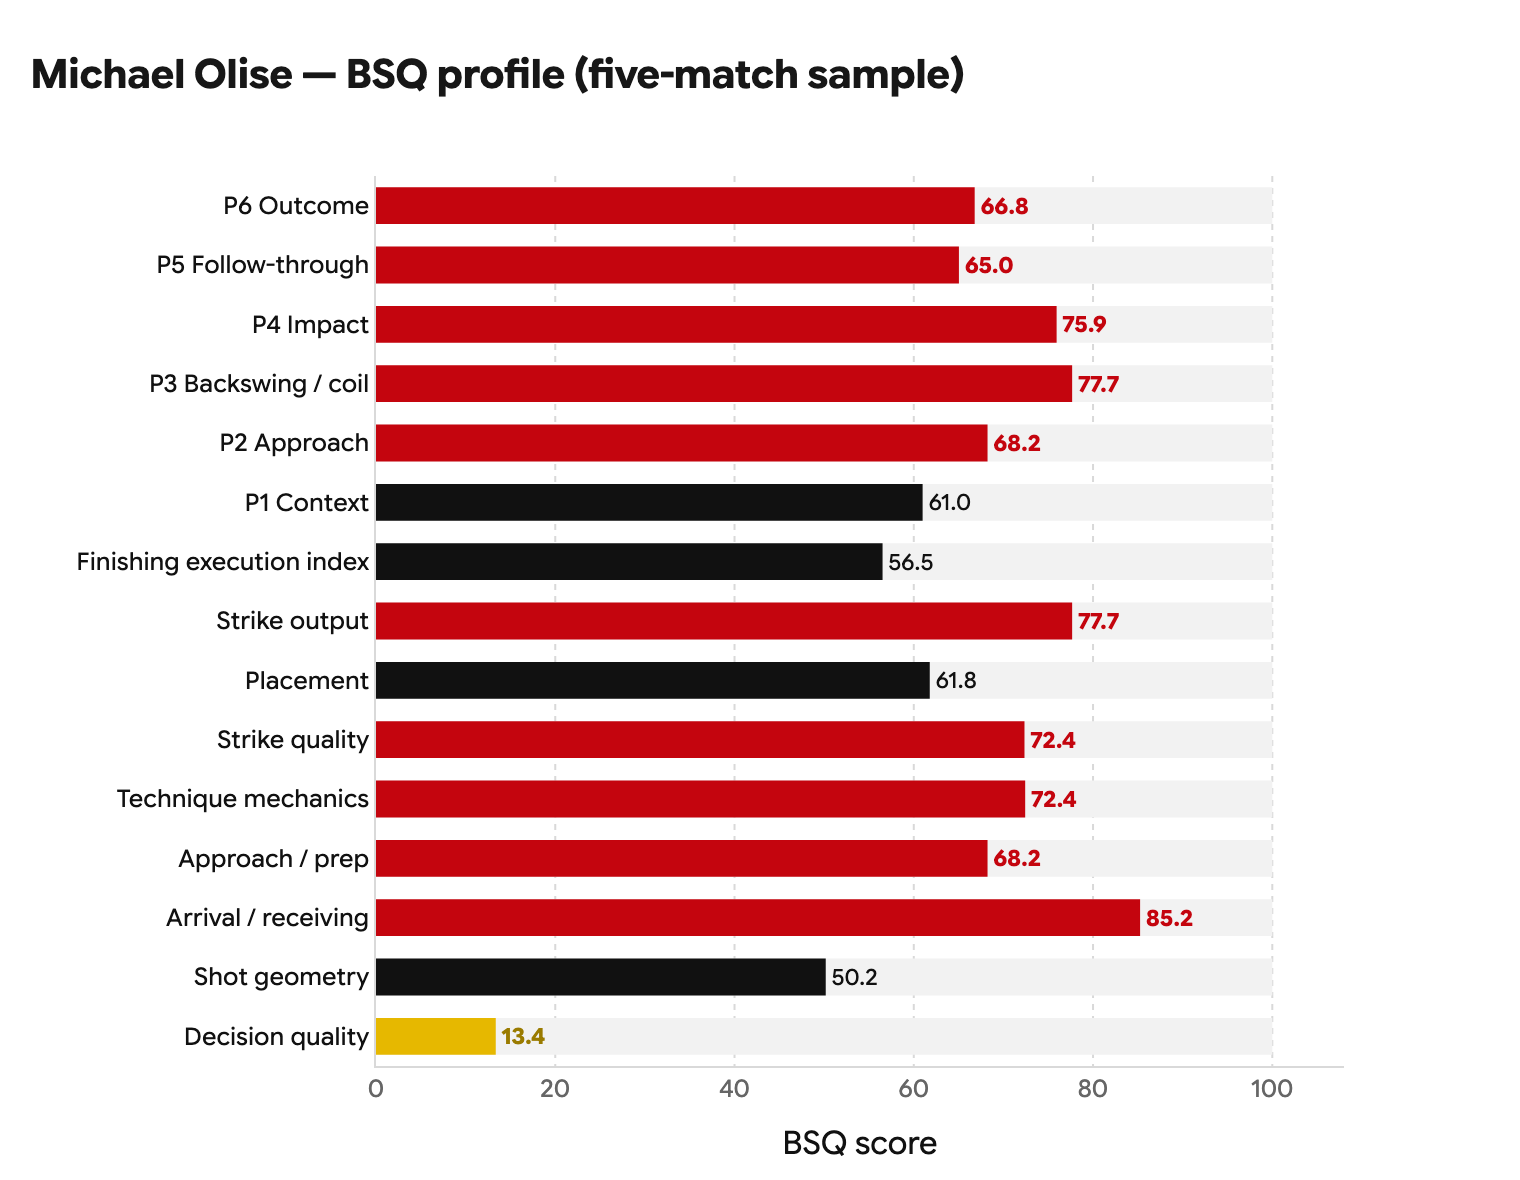

In [4]:
display_plotly_player_dashboard(means, PLAYER)


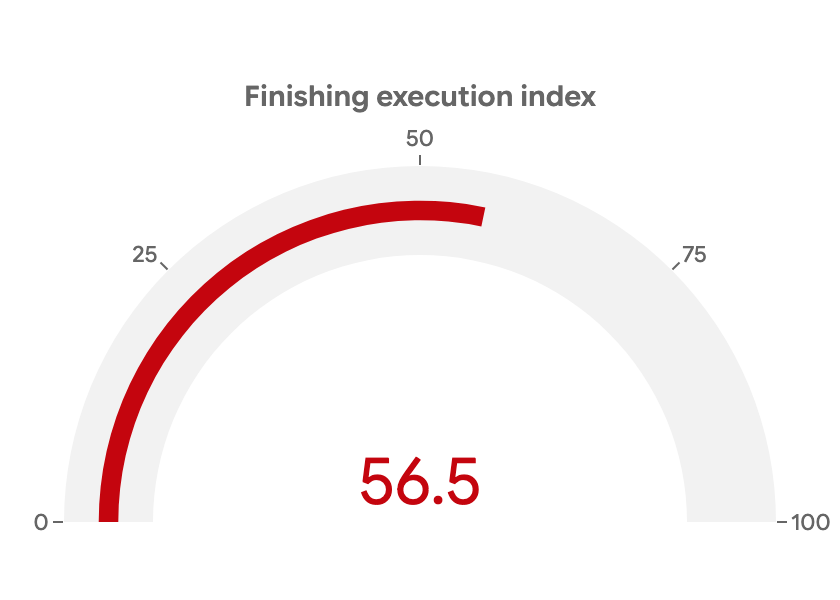

In [5]:
display_plotly_speedometer('Finishing execution index', means['finishing_execution_index'])


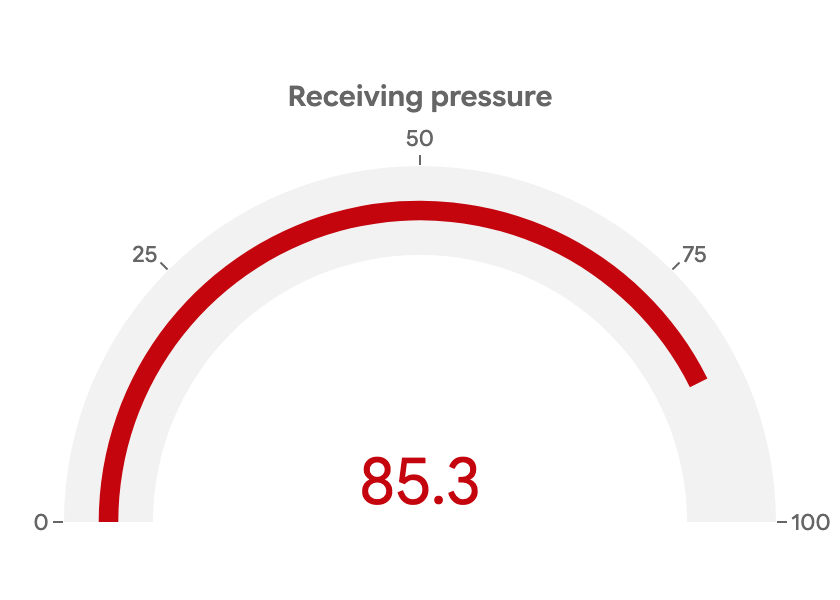

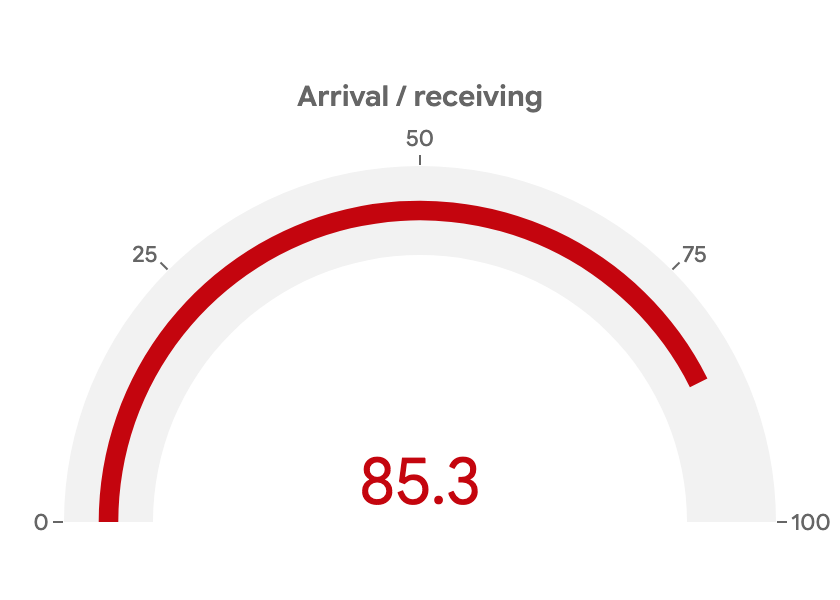

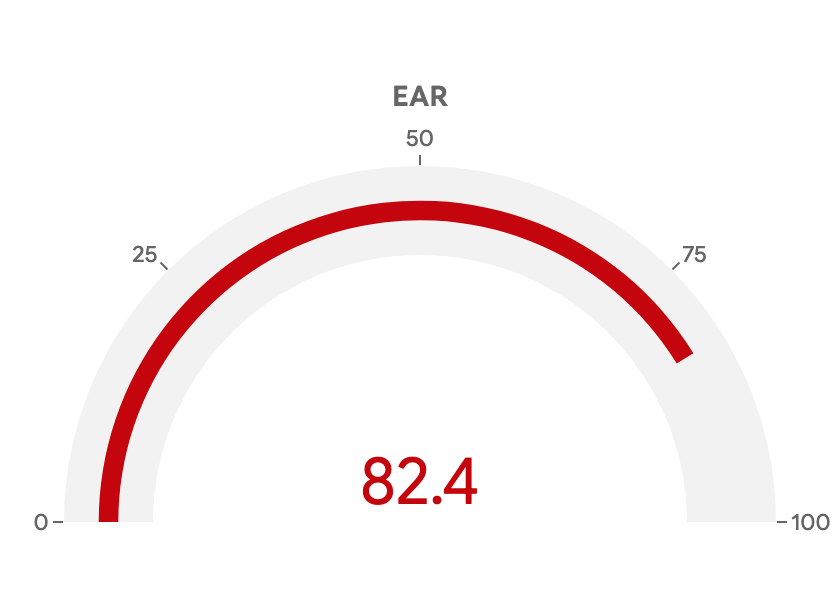

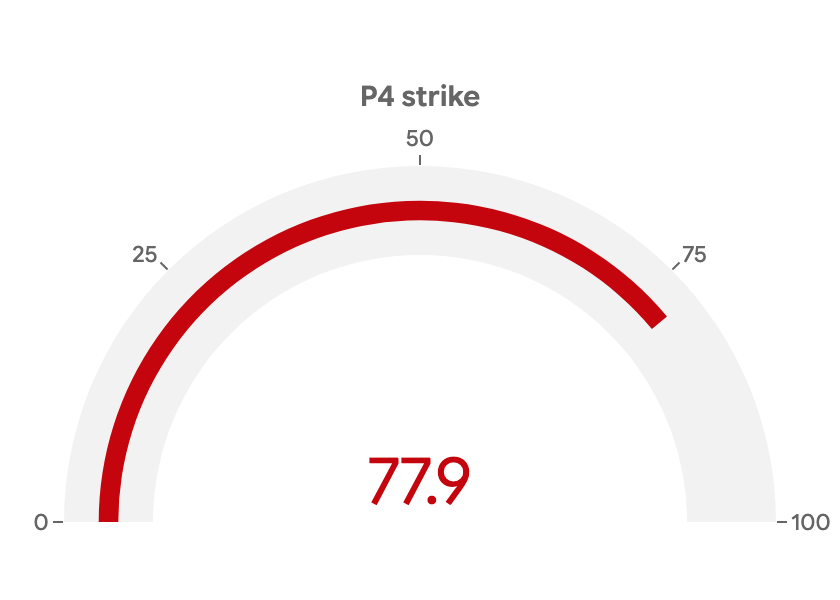

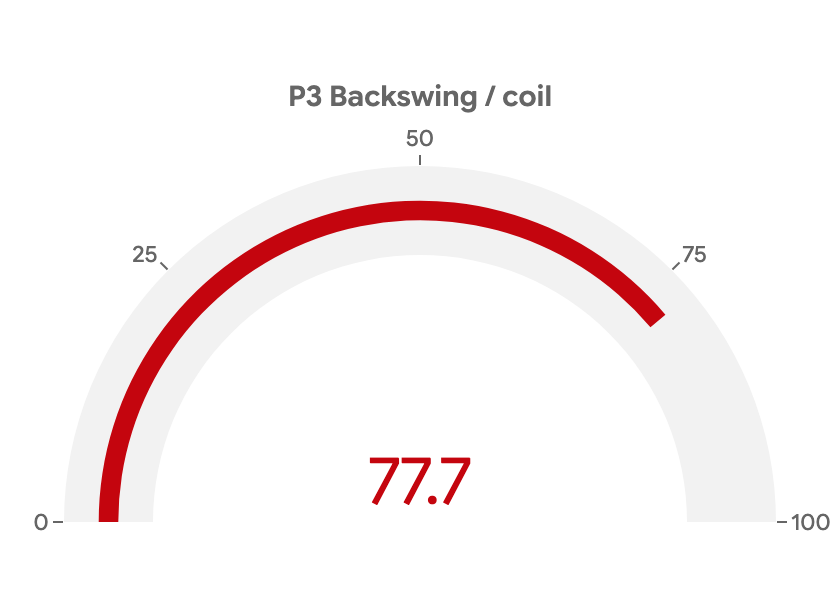

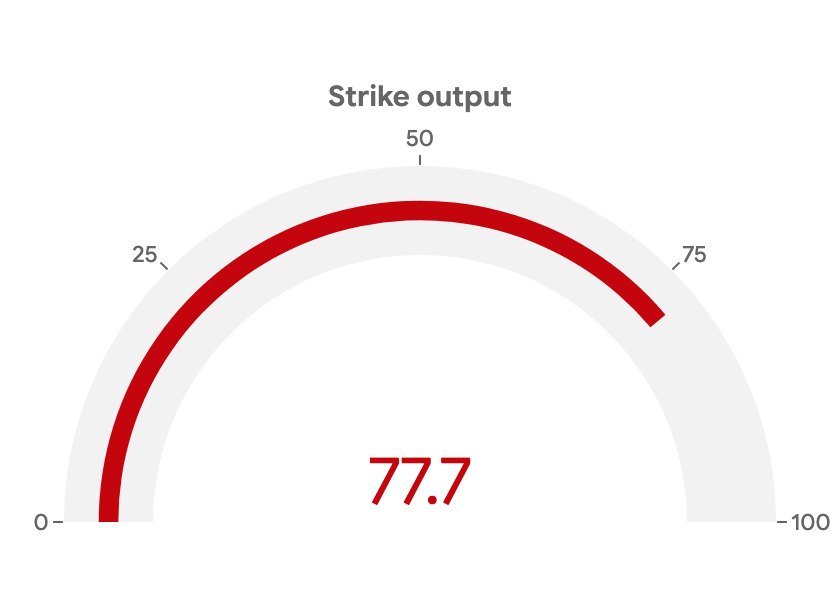

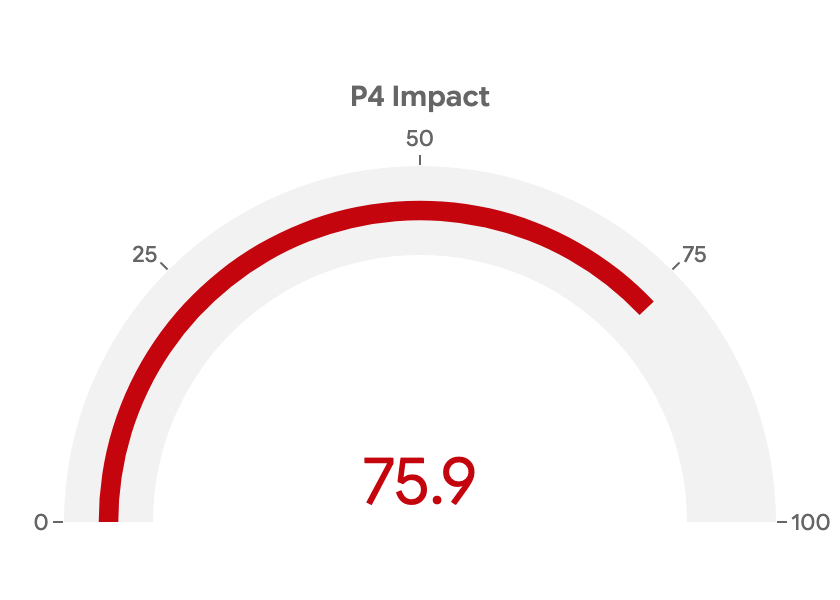

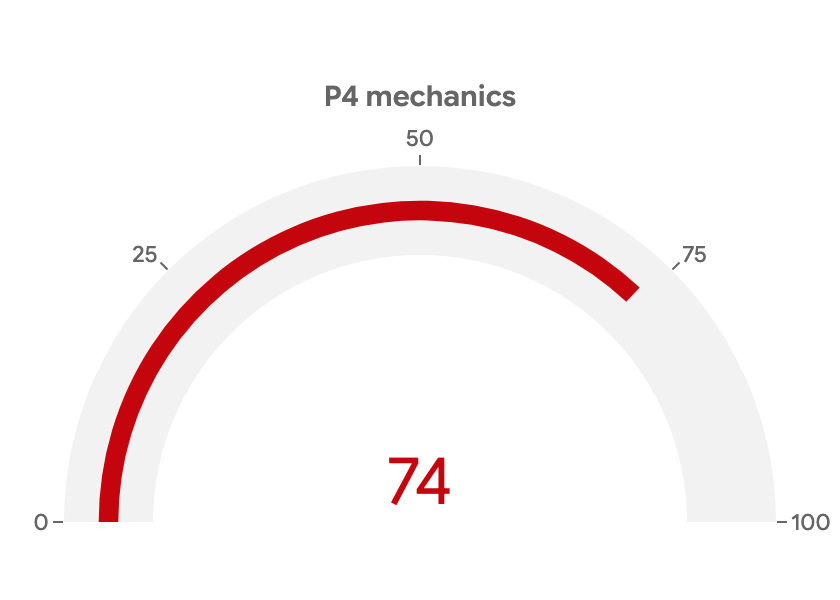

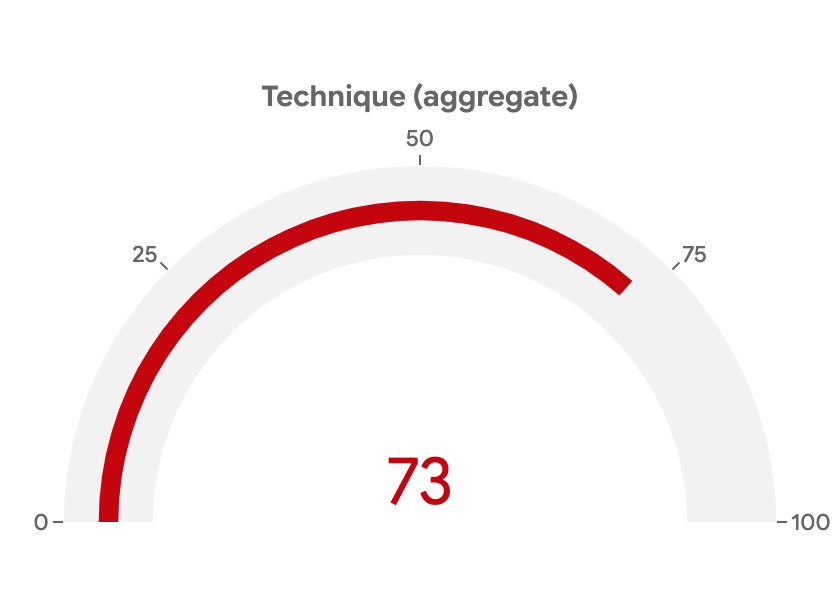

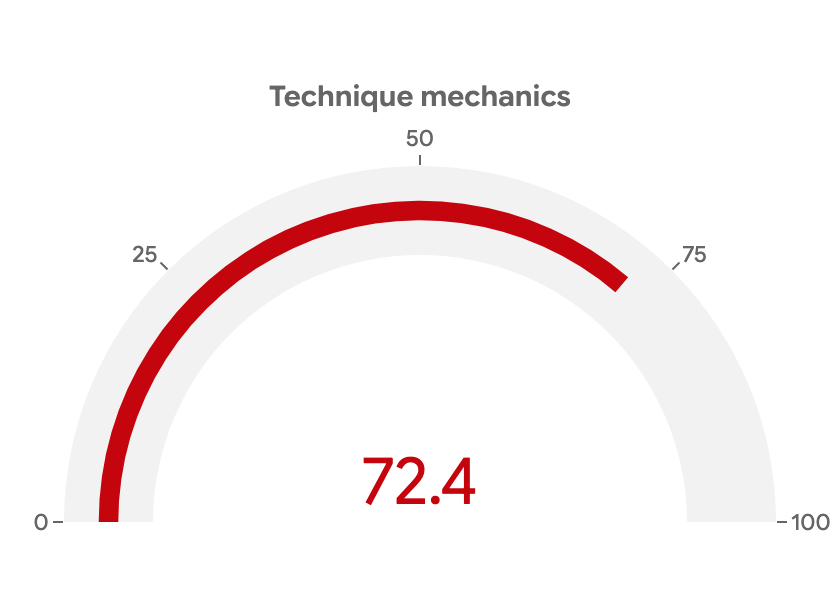

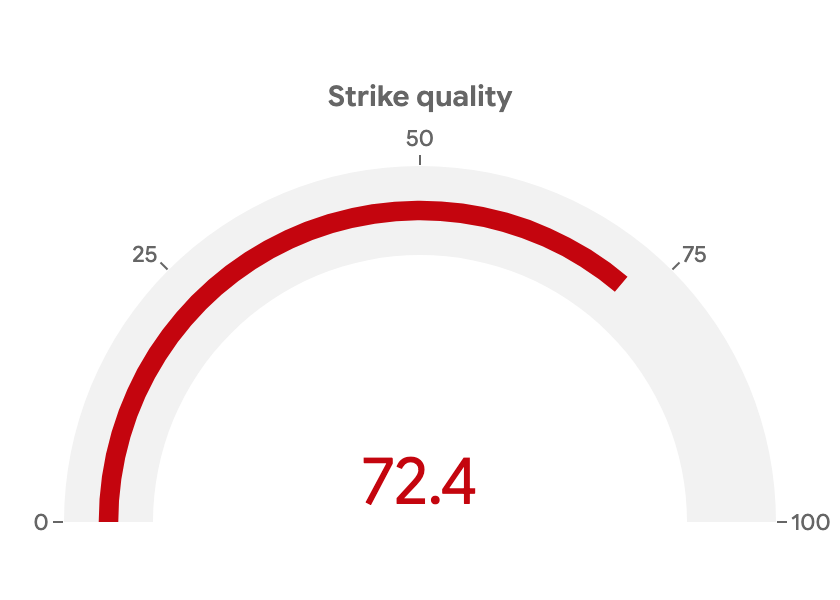

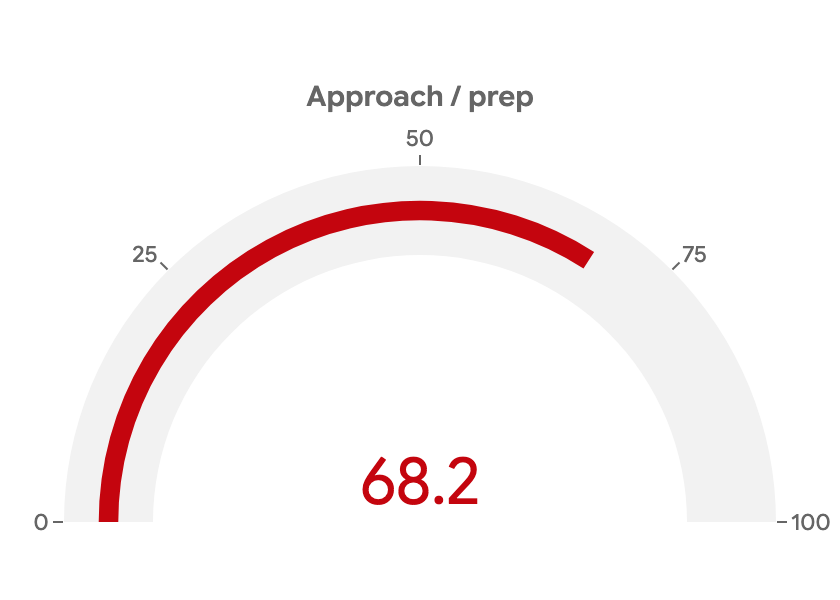

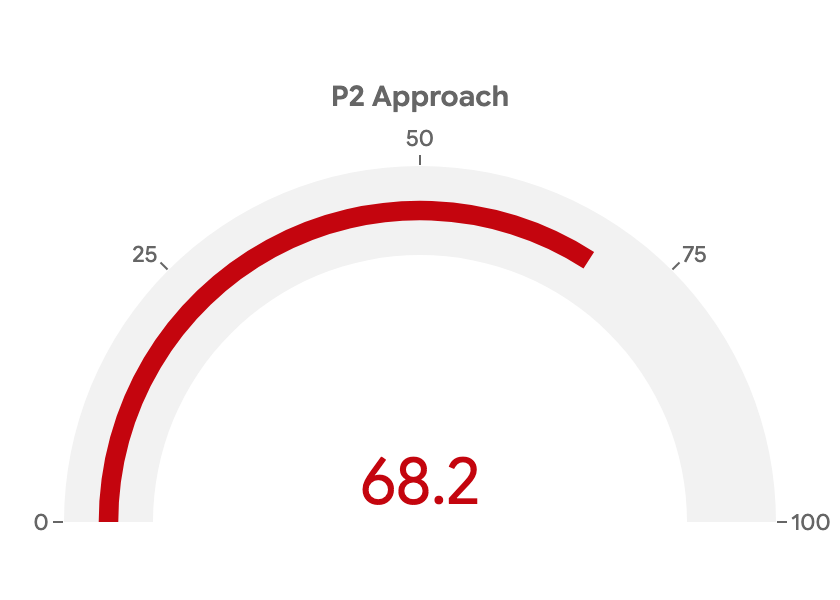

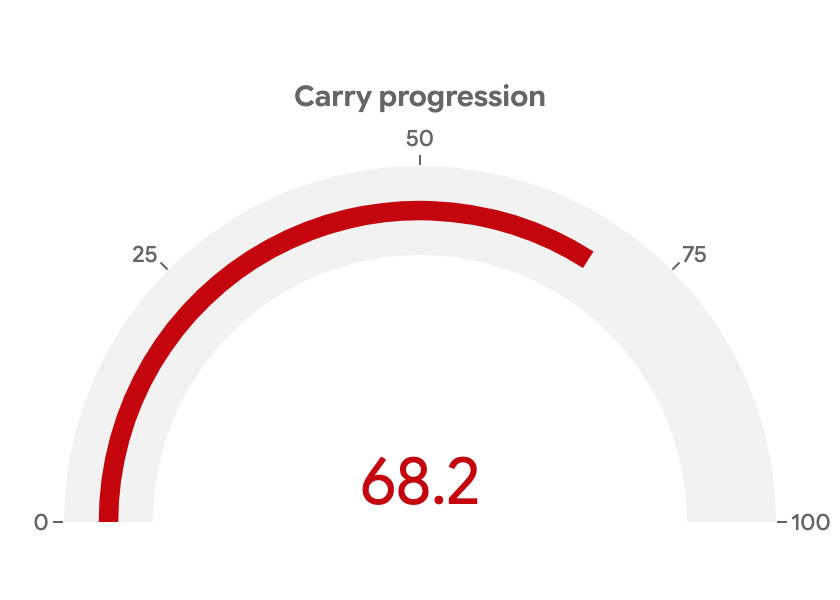

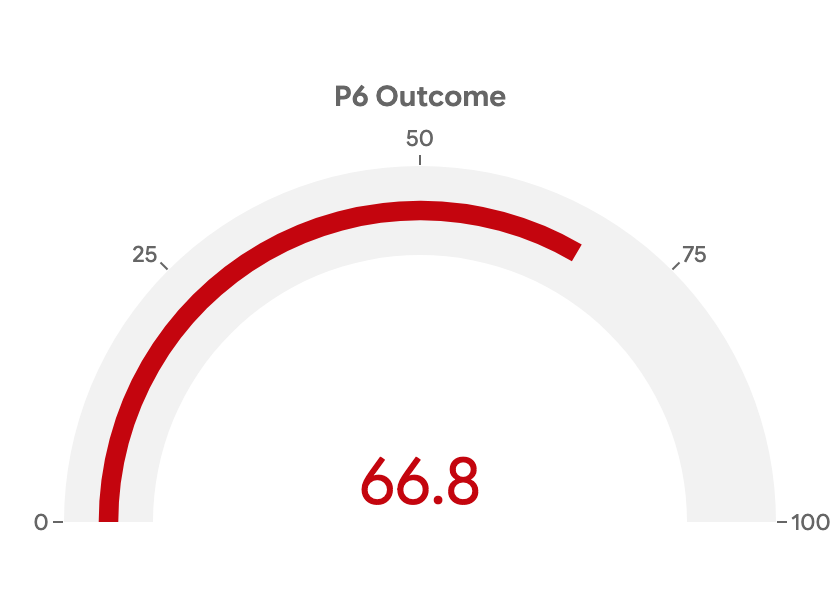

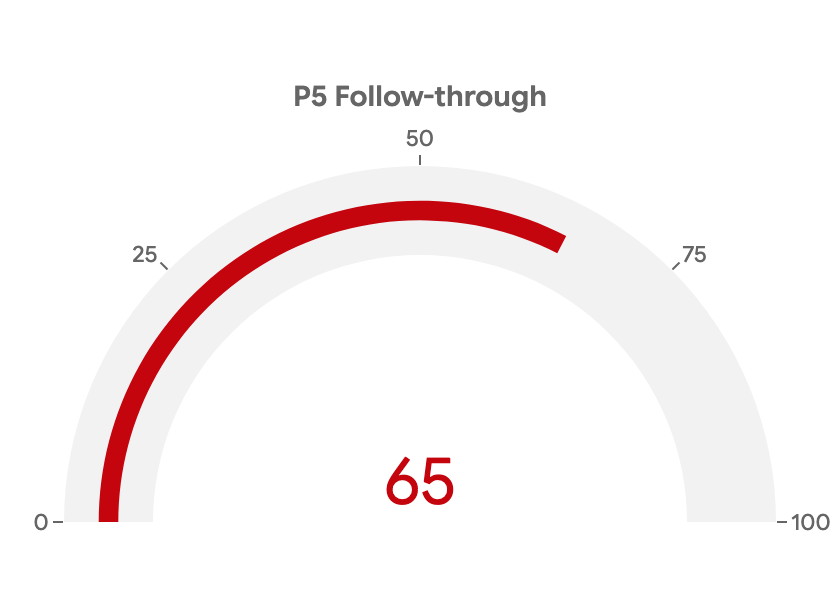

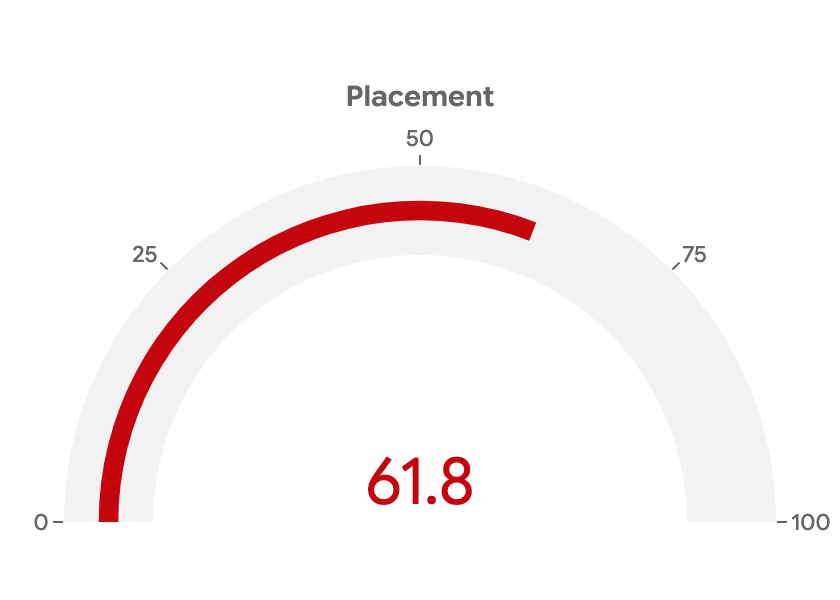

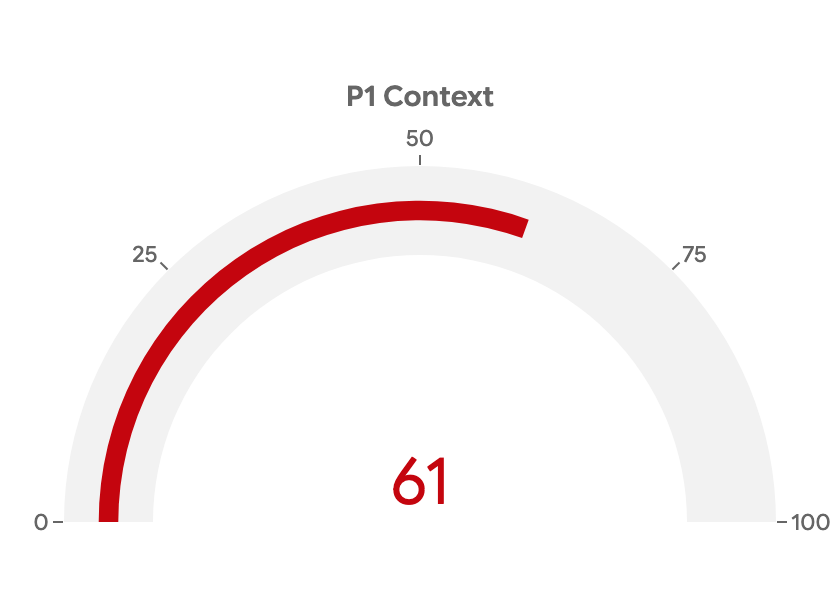

[('Receiving pressure', 85.25),
 ('Arrival / receiving', 85.25),
 ('EAR', 82.39576677133002),
 ('P4 strike', 77.908148221428),
 ('P3 Backswing / coil', 77.66786584027588),
 ('Strike output', 77.6675704136794),
 ('P4 Impact', 75.93643313566605),
 ('P4 mechanics', 73.96471804990412),
 ('Technique (aggregate)', 72.98958827970048),
 ('Technique mechanics', 72.42985226278313),
 ('Strike quality', 72.35102569140983),
 ('Approach / prep', 68.22930765158566),
 ('P2 Approach', 68.22930765158566),
 ('Carry progression', 68.15982142857143),
 ('P6 Outcome', 66.79390316139168),
 ('P5 Follow-through', 65.03722522748039),
 ('Placement', 61.78360235528142),
 ('P1 Context', 60.98758081652505)]

In [6]:
highlights = display_player_speedometers(means, min_score=60)
highlights


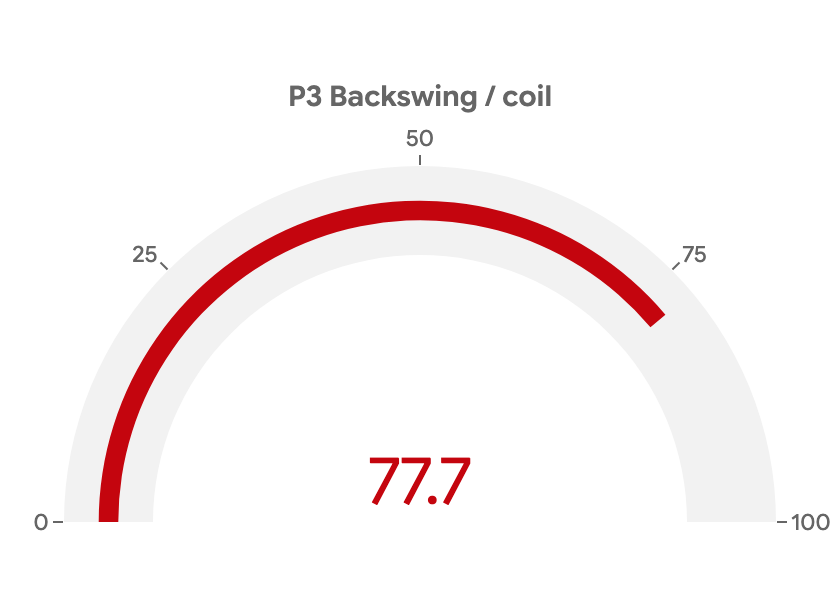

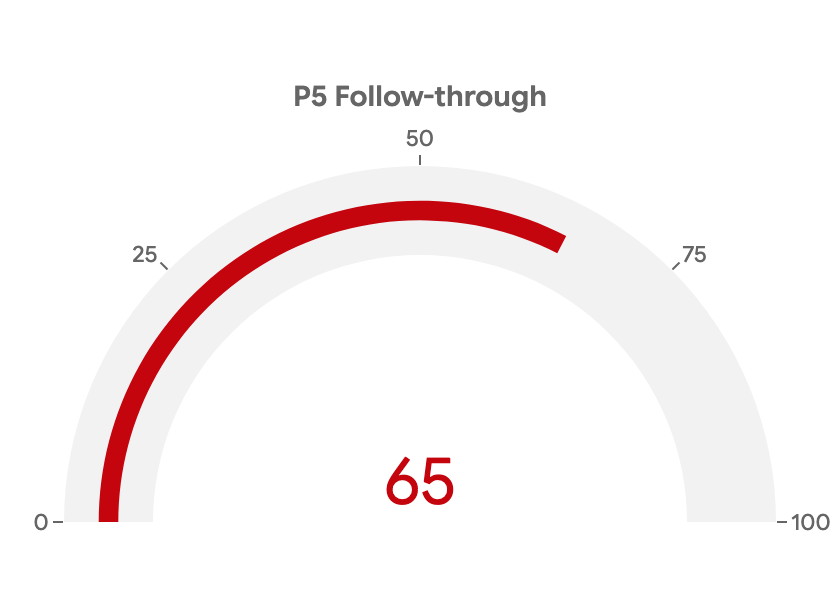

In [7]:
display_plotly_phase_speedometer(means, BACKSWING_PHASE_LABEL)
display_plotly_phase_speedometer(means, FOLLOW_THROUGH_PHASE_LABEL)
